<a href="https://colab.research.google.com/github/SeratAftab131/Ocular-Disease-Prediction/blob/main/Ocular_disease_prediction_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Verification and Environment Set-Up

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import pandas as pd
from PIL import Image

train_dir = '/content/drive/MyDrive/Thesis/ODIR-5K/ODIR-5K/Training Images'
test_dir  = '/content/drive/MyDrive/Thesis/ODIR-5K/ODIR-5K/Testing Images'
pre_dir   = '/content/drive/MyDrive/Thesis/preprocessed_images'
csv_path  = '/content/drive/MyDrive/Thesis/full_df.csv'

df = pd.read_csv(csv_path)
print("=== CSV ===")
print("Shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Duplicates:", df.duplicated().sum())
print("Label columns sample:")
print(df[['filename','N','D','G','C','A','H','M','O']].head(5).to_string())

for label, path in [('Training Images', train_dir),
                    ('Testing Images',  test_dir),
                    ('preprocessed',    pre_dir)]:
    files = [f for f in os.listdir(path) if f.lower().endswith(('.jpg','.jpeg','.png'))]
    print(f"\n=== {label}: {len(files)} images ===")
    sizes = set()
    for f in files[:10]:
        img = Image.open(os.path.join(path, f))
        sizes.add(img.size)
    print(f"  Unique sizes in first 10: {sizes}")
    arr = np.array(Image.open(os.path.join(path, files[0])))
    print(f"  Pixel range: {arr.min()} – {arr.max()}")
    print(f"  Sample filenames: {files[:3]}")

train_files = set(os.listdir(train_dir))
matched = df['filename'].isin(train_files).sum()
print(f"\n=== Filename match: {matched}/{len(df)} CSV filenames found in Training Images ===")

Mounted at /content/drive
=== CSV ===
Shape: (6392, 19)
Missing values: 0
Duplicates: 0
Label columns sample:
      filename  N  D  G  C  A  H  M  O
0  0_right.jpg  0  0  0  1  0  0  0  0
1  1_right.jpg  1  0  0  0  0  0  0  0
2  2_right.jpg  0  1  0  0  0  0  0  1
3  4_right.jpg  0  1  0  0  0  0  0  1
4  5_right.jpg  0  1  0  0  0  0  0  0

=== Training Images: 7000 images ===
  Unique sizes in first 10: {(2048, 1536), (1380, 1382), (2592, 1944), (2460, 1904), (2304, 1728), (2592, 1728), (1624, 1232), (1920, 1296)}
  Pixel range: 0 – 255
  Sample filenames: ['542_left.jpg', '554_right.jpg', '552_right.jpg']

=== Testing Images: 1000 images ===
  Unique sizes in first 10: {(1936, 1296), (2048, 1536), (2592, 1728)}
  Pixel range: 0 – 251
  Sample filenames: ['1000_right.jpg', '1000_left.jpg', '1001_left.jpg']

=== preprocessed: 6392 images ===
  Unique sizes in first 10: {(512, 512)}
  Pixel range: 0 – 254
  Sample filenames: ['4635_left.jpg', '545_right.jpg', '576_right.jpg']

=== Fil

# Data Analysis

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

df = pd.read_csv(csv_path)

disease_cols = ['N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']
disease_names = ['Normal', 'Diabetic Retinopathy', 'Glaucoma', 'Cataract',
                 'AMD', 'Hypertension', 'Pathological Myopia', 'Other']

class_counts   = df[disease_cols].sum().values
multi_label    = (df[disease_cols].sum(axis=1) > 1).sum()
single_label   = len(df) - multi_label
gender_counts  = df['Patient Sex'].value_counts()

fig = plt.figure(figsize=(18, 14))
fig.suptitle('ODIR-5K Dataset — Exploratory Data Analysis', fontsize=16, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

ax1 = fig.add_subplot(gs[0, :2])
colors = ['#2ecc71' if n == 'Normal' else '#e74c3c' for n in disease_names]
bars = ax1.bar(disease_names, class_counts, color=colors, edgecolor='white', linewidth=0.8)
ax1.set_title('Class Distribution (No. of Images per Disease)', fontweight='bold')
ax1.set_xlabel('Disease Class')
ax1.set_ylabel('Number of Images')
ax1.set_xticklabels(disease_names, rotation=25, ha='right')
for bar, count in zip(bars, class_counts):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
             str(count), ha='center', va='bottom', fontsize=10, fontweight='bold')
ax1.spines[['top','right']].set_visible(False)

ax2 = fig.add_subplot(gs[0, 2])
ax2.pie(gender_counts.values,
        labels=gender_counts.index,
        autopct='%1.1f%%',
        colors=['#3498db','#e91e8c'],
        startangle=90,
        wedgeprops={'edgecolor':'white','linewidth':1.5})
ax2.set_title('Gender Distribution', fontweight='bold')

ax3 = fig.add_subplot(gs[1, :2])
ax3.hist(df['Patient Age'], bins=20, color='#9b59b6', edgecolor='white', linewidth=0.8)
ax3.set_title('Patient Age Distribution', fontweight='bold')
ax3.set_xlabel('Age')
ax3.set_ylabel('Number of Patients')
ax3.axvline(df['Patient Age'].mean(), color='#e74c3c', linestyle='--', linewidth=1.5,
            label=f"Mean age: {df['Patient Age'].mean():.1f}")
ax3.legend()
ax3.spines[['top','right']].set_visible(False)

ax4 = fig.add_subplot(gs[1, 2])
ax4.pie([single_label, multi_label],
        labels=[f'Single label\n({single_label})', f'Multi-label\n({multi_label})'],
        autopct='%1.1f%%',
        colors=['#3498db','#e67e22'],
        startangle=90,
        wedgeprops={'edgecolor':'white','linewidth':1.5})
ax4.set_title('Single vs Multi-Label Images', fontweight='bold')

plt.savefig('/content/drive/MyDrive/Thesis/eda_charts.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== Dataset Summary ===")
print(f"Total images       : {len(df)}")
print(f"Multi-label images : {multi_label} ({multi_label/len(df)*100:.1f}%)")
print(f"Single-label images: {single_label} ({single_label/len(df)*100:.1f}%)")
print(f"\nClass counts:")
for name, count in zip(disease_names, class_counts):
    print(f"  {name:<25}: {count}")
print(f"\nAge — mean: {df['Patient Age'].mean():.1f}, "
      f"min: {df['Patient Age'].min()}, max: {df['Patient Age'].max()}")
print(f"\nGender:\n{gender_counts.to_string()}")

# Data Generator & Preprocessing Pipeline

In [2]:
import os
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

pre_dir  = '/content/drive/MyDrive/Thesis/preprocessed_images'
csv_path = '/content/drive/MyDrive/Thesis/full_df.csv'

df = pd.read_csv(csv_path)

disease_cols = ['N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']

df['full_path'] = df['filename'].apply(lambda x: os.path.join(pre_dir, x))
missing = df[~df['full_path'].apply(os.path.exists)]
print(f"Missing images: {len(missing)}")

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['D']
)
print(f"Train size : {len(train_df)}")
print(f"Val size   : {len(val_df)}")

def create_generator(dataframe, image_dir, batch_size=32,
                     target_size=(224, 224), augment=False, shuffle=True):

    datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=15      if augment else 0,
        horizontal_flip=True   if augment else False,
        zoom_range=0.1         if augment else 0,
        brightness_range=[0.8, 1.2] if augment else None,
    )

    generator = datagen.flow_from_dataframe(
        dataframe=dataframe,
        directory=image_dir,
        x_col='filename',
        y_col=disease_cols,
        class_mode='raw',
        target_size=target_size,
        batch_size=batch_size,
        shuffle=shuffle,
    )
    return generator

train_gen = create_generator(train_df, pre_dir, augment=True,  shuffle=True)
val_gen   = create_generator(val_df,   pre_dir, augment=False, shuffle=False)

print(f"\nTrain batches : {len(train_gen)}")
print(f"Val batches   : {len(val_gen)}")

images, labels = next(train_gen)
print(f"\nBatch image shape : {images.shape}")
print(f"Batch label shape : {labels.shape}")
print(f"Pixel range       : {images.min():.2f} – {images.max():.2f}")
print(f"Sample label      : {labels[0]}")

total = len(train_df)
class_weights = {}
for i, col in enumerate(disease_cols):
    pos = train_df[col].sum()
    neg = total - pos
    class_weights[i] = round(neg / (pos + 1e-6), 2)

print("\nClass weights (higher = rarer class):")
for col, w in zip(disease_cols, class_weights.values()):
    print(f"  {col} : {w}")

Missing images: 0
Train size : 5113
Val size   : 1279
Found 5113 validated image filenames.
Found 1279 validated image filenames.

Train batches : 160
Val batches   : 40

Batch image shape : (32, 224, 224, 3)
Batch label shape : (32, 8)
Pixel range       : 0.00 – 1.00
Sample label      : [0 1 0 0 0 0 0 0]

Class weights (higher = rarer class):
  N : 2.05
  D : 2.01
  G : 15.65
  C : 15.28
  A : 18.15
  H : 33.09
  M : 20.85
  O : 3.0


# 	Disease Co-occurrence Analysis

=== Co-occurrence Matrix ===
   N    D   G   C   A   H   M    O
N  0    0   0   0   0   0   0    0
D  0    0  56  74  32  89  36  497
G  0   56   0   6  20  15  13   78
C  0   74   6   0   0   4   0   56
A  0   32  20   0   0   8   4   26
H  0   89  15   4   8   0   0   21
M  0   36  13   0   4   0   0   58
O  0  497  78  56  26  21  58    0

=== Top Co-occurring Disease Pairs ===
   Disease 1 Disease 2  Count
0          D         O    497
1          D         H     89
2          G         O     78
3          D         C     74
4          M         O     58
5          D         G     56
6          C         O     56
7          D         M     36
8          D         A     32
9          A         O     26
10         H         O     21
11         G         A     20
12         G         H     15
13         G         M     13
14         A         H      8
15         G         C      6
16         C         H      4
17         A         M      4


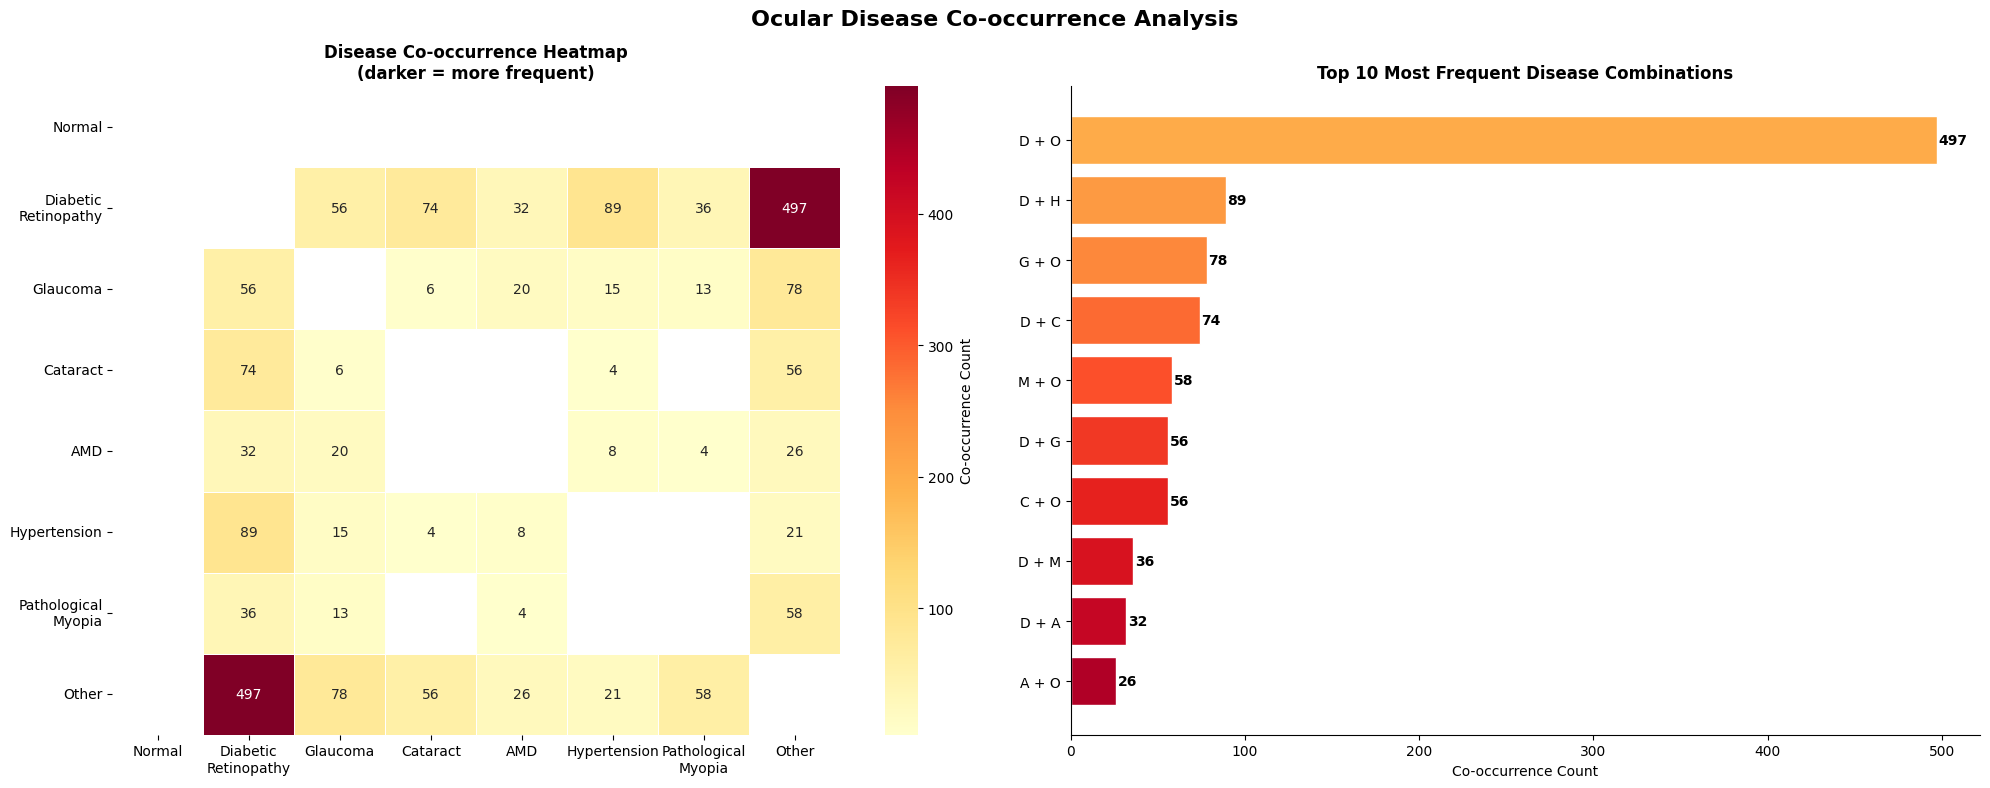


=== Key Insights ===
Total multi-label images     : 1001
Total unique co-occurring pairs found : 18

Most frequent pair : D + O (497 images)
Least frequent pair: A + M (4 images)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

csv_path = '/content/drive/MyDrive/Thesis/full_df.csv'
df = pd.read_csv(csv_path)

disease_cols  = ['N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']
disease_names = ['Normal', 'Diabetic\nRetinopathy', 'Glaucoma', 'Cataract',
                 'AMD', 'Hypertension', 'Pathological\nMyopia', 'Other']

co_matrix = pd.DataFrame(np.zeros((8, 8), dtype=int),
                         index=disease_cols,
                         columns=disease_cols)

for _, row in df.iterrows():
    diseases = [col for col in disease_cols if row[col] == 1]
    for d1, d2 in combinations(diseases, 2):
        co_matrix.loc[d1, d2] += 1
        co_matrix.loc[d2, d1] += 1

print("=== Co-occurrence Matrix ===")
print(co_matrix.to_string())

pairs = []
for d1, d2 in combinations(disease_cols, 2):
    count = co_matrix.loc[d1, d2]
    if count > 0:
        pairs.append((d1, d2, count))

pairs_df = pd.DataFrame(pairs, columns=['Disease 1', 'Disease 2', 'Count'])
pairs_df = pairs_df.sort_values('Count', ascending=False).reset_index(drop=True)

print("\n=== Top Co-occurring Disease Pairs ===")
print(pairs_df.to_string())

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('Ocular Disease Co-occurrence Analysis', fontsize=16, fontweight='bold')

mask = co_matrix == 0
sns.heatmap(co_matrix,
            ax=axes[0],
            annot=True,
            fmt='d',
            cmap='YlOrRd',
            xticklabels=disease_names,
            yticklabels=disease_names,
            linewidths=0.5,
            linecolor='white',
            mask=mask,
            cbar_kws={'label': 'Co-occurrence Count'})
axes[0].set_title('Disease Co-occurrence Heatmap\n(darker = more frequent)', fontweight='bold')
axes[0].tick_params(axis='x', rotation=0)
axes[0].tick_params(axis='y', rotation=0)

top_pairs = pairs_df.head(10)
pair_labels = [f"{r['Disease 1']} + {r['Disease 2']}" for _, r in top_pairs.iterrows()]
bar_colors = plt.cm.YlOrRd(np.linspace(0.4, 0.9, len(top_pairs)))
bars = axes[1].barh(pair_labels[::-1], top_pairs['Count'].values[::-1],
                    color=bar_colors[::-1], edgecolor='white')
axes[1].set_title('Top 10 Most Frequent Disease Combinations', fontweight='bold')
axes[1].set_xlabel('Co-occurrence Count')
for bar, count in zip(bars, top_pairs['Count'].values[::-1]):
    axes[1].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                 str(count), va='center', fontweight='bold')
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Thesis/co_occurrence.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== Key Insights ===")
print(f"Total multi-label images     : {(df[disease_cols].sum(axis=1) > 1).sum()}")
print(f"Total unique co-occurring pairs found : {len(pairs_df)}")
print(f"\nMost frequent pair : {pairs_df.iloc[0]['Disease 1']} + "
      f"{pairs_df.iloc[0]['Disease 2']} ({pairs_df.iloc[0]['Count']} images)")
print(f"Least frequent pair: {pairs_df.iloc[-1]['Disease 1']} + "
      f"{pairs_df.iloc[-1]['Disease 2']} ({pairs_df.iloc[-1]['Count']} images)")

# 	Model Architecture

In [3]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0, DenseNet121, ResNet50

IMG_SIZE    = (224, 224, 3)
NUM_CLASSES = 8
DROPOUT     = 0.5
DENSE_UNITS = 256

def build_top(base_output):
    x = layers.GlobalAveragePooling2D()(base_output)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(DENSE_UNITS, activation='relu')(x)
    x = layers.Dropout(DROPOUT)(x)
    output = layers.Dense(NUM_CLASSES, activation='sigmoid')(x)
    return output

def build_model(base_model, name):
    base_model.trainable = False
    inputs  = base_model.input
    outputs = build_top(base_model.output)
    model   = Model(inputs, outputs, name=name)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc', multi_label=True)]
    )
    return model

mobilenet_base     = MobileNetV2(include_top=False, weights='imagenet', input_shape=IMG_SIZE)
efficientnet_base  = EfficientNetB0(include_top=False, weights='imagenet', input_shape=IMG_SIZE)
densenet_base      = DenseNet121(include_top=False, weights='imagenet', input_shape=IMG_SIZE)
resnet_base        = ResNet50(include_top=False, weights='imagenet', input_shape=IMG_SIZE)

mobilenet_model    = build_model(mobilenet_base,    'MobileNetV2')
efficientnet_model = build_model(efficientnet_base, 'EfficientNetB0')
densenet_model     = build_model(densenet_base,     'DenseNet121')
resnet_model       = build_model(resnet_base,       'ResNet50')

for model in [mobilenet_model, efficientnet_model, densenet_model, resnet_model]:
    print(f"\n{'='*60}")
    print(f"Model : {model.name}")
    print(f"Total params     : {model.count_params():,}")
    print(f"Trainable params : {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}")
    print(f"Output shape     : {model.output_shape}")

print("\n✅ All four models built successfully.")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step

Model : MobileNetV2
Total params     : 2,593,096
Trainable params : 332,552
Output shape     : (None, 8)

Model : EfficientNetB0
Total params     : 4,384,683
Trainable params : 332,552
Output shape     : (None, 8)

Model : DenseNet121
Total params     : 7,306,056
Trainable params : 266,504
Output shape     : (None, 8)

Model : ResNet50
Total params     : 24,122,504
Trainable params : 530,696
Output shape     : (None, 8)

✅ All four models built successfully.


In [4]:
import tensorflow as tf
print("GPU available:", tf.config.list_physical_devices('GPU'))
print("Device:", tf.test.gpu_device_name())

GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Device: /device:GPU:0


# MobileNetV2

In [ ]:
import os
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

save_dir = '/content/drive/MyDrive/Thesis/saved_models'
os.makedirs(save_dir, exist_ok=True)

def get_callbacks(model_name):
    return [
        ModelCheckpoint(
            filepath=os.path.join(save_dir, f'{model_name}_best.h5'),
            monitor='val_auc',
            mode='max',
            save_best_only=True,
            verbose=1
        ),
        EarlyStopping(
            monitor='val_auc',
            mode='max',
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_auc',
            mode='max',
            factor=0.5,
            patience=3,
            min_lr=1e-7,
            verbose=1
        )
    ]


print("="*60)
print("Training MobileNetV2")
print("="*60)

print("\nPhase 1 — Feature Extraction (base frozen)")
print("-"*40)

mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc', multi_label=True)]
)

history_phase1_mobilenet = mobilenet_model.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen,
    class_weight=class_weights,
    callbacks=get_callbacks('mobilenet_phase1'),
    verbose=1
)

print("\nPhase 2 — Fine Tuning (unfreezing last 20 layers)")
print("-"*40)

mobilenet_base.trainable = True
for layer in mobilenet_base.layers[:-20]:
    layer.trainable = False

mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc', multi_label=True)]
)

print(f"Trainable layers in Phase 2: "
      f"{sum([1 for l in mobilenet_model.layers if l.trainable])}")

history_phase2_mobilenet = mobilenet_model.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen,
    class_weight=class_weights,
    callbacks=get_callbacks('mobilenet_phase2'),
    verbose=1
)

mobilenet_model.save(os.path.join(save_dir, 'mobilenet_final.h5'))
print("\n MobileNetV2 training complete — model saved to Drive")

best_auc_p1 = max(history_phase1_mobilenet.history['val_auc'])
best_auc_p2 = max(history_phase2_mobilenet.history['val_auc'])
print(f"\nMobileNetV2 Results:")
print(f"  Phase 1 best val AUC : {best_auc_p1:.4f}")
print(f"  Phase 2 best val AUC : {best_auc_p2:.4f}")
print(f"  Improvement          : {(best_auc_p2 - best_auc_p1):.4f}")

Training MobileNetV2

Phase 1 — Feature Extraction (base frozen)
----------------------------------------
Epoch 1/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.2160 - auc: 0.6435 - loss: 2.8350 
Epoch 1: val_auc improved from None to 0.73676, saving model to /content/drive/MyDrive/Thesis/saved_models/mobilenet_phase1_best.h5



Epoch 1: finished saving model to /content/drive/MyDrive/Thesis/saved_models/mobilenet_phase1_best.h5
160/160 ━━━━━━━━━━━━━━━━━━━━ 2540s 16s/step - accuracy: 0.2292 - auc: 0.6700 - loss: 2.4878 - val_accuracy: 0.3057 - val_auc: 0.7368 - val_loss: 0.3824 - learning_rate: 0.0010
Epoch 2/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 549ms/step - accuracy: 0.2656 - auc: 0.7318 - loss: 1.9868
Epoch 2: val_auc improved from 0.73676 to 0.75113, saving model to /content/drive/MyDrive/Thesis/saved_models/mobilenet_phase1_best.h5



Epoch 2: finished saving model to /content/drive/MyDrive/Thesis/saved_models/mobilenet_phase1_best.h5
160/160 ━━━━━━━━━━━━━━━━━━━━ 95s 592ms/step - accuracy: 0.2809 - auc: 0.7286 - loss: 1.9623 - val_accuracy: 0.3112 - val_auc: 0.7511 - val_loss: 0.3579 - learning_rate: 0.0010
Epoch 3/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 545ms/step - accuracy: 0.2888 - auc: 0.7564 - loss: 1.7696
Epoch 3: val_auc improved from 0.75113 to 0.75627, saving model to /content/drive/MyDrive/Thesis/saved_models/mobilenet_phase1_best.h5



Epoch 3: finished saving model to /content/drive/MyDrive/Thesis/saved_models/mobilenet_phase1_best.h5
160/160 ━━━━━━━━━━━━━━━━━━━━ 93s 584ms/step - accuracy: 0.2965 - auc: 0.7472 - loss: 1.7822 - val_accuracy: 0.3034 - val_auc: 0.7563 - val_loss: 0.3527 - learning_rate: 0.0010
Epoch 4/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 537ms/step - accuracy: 0.3126 - auc: 0.7655 - loss: 1.7084
Epoch 4: val_auc improved from 0.75627 to 0.76933, saving model to /content/drive/MyDrive/Thesis/saved_models/mobilenet_phase1_best.h5



Epoch 4: finished saving model to /content/drive/MyDrive/Thesis/saved_models/mobilenet_phase1_best.h5
160/160 ━━━━━━━━━━━━━━━━━━━━ 93s 579ms/step - accuracy: 0.3180 - auc: 0.7702 - loss: 1.6467 - val_accuracy: 0.3339 - val_auc: 0.7693 - val_loss: 0.3445 - learning_rate: 0.0010
Epoch 5/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 538ms/step - accuracy: 0.3408 - auc: 0.7795 - loss: 1.5156
Epoch 5: val_auc did not improve from 0.76933
160/160 ━━━━━━━━━━━━━━━━━━━━ 91s 570ms/step - accuracy: 0.3337 - auc: 0.7783 - loss: 1.5534 - val_accuracy: 0.3565 - val_auc: 0.7636 - val_loss: 0.3407 - learning_rate: 0.0010
Epoch 6/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 571ms/step - accuracy: 0.3306 - auc: 0.7911 - loss: 1.5018
Epoch 6: val_auc did not improve from 0.76933
160/160 ━━━━━━━━━━━━━━━━━━━━ 97s 603ms/step - accuracy: 0.3346 - auc: 0.7885 - loss: 1.4953 - val_accuracy: 0.3745 - val_auc: 0.7656 - val_loss: 0.3326 - learning_rate: 0.0010
Epoch 7/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 536ms/step - accuracy: 0.3645 


Epoch 8: finished saving model to /content/drive/MyDrive/Thesis/saved_models/mobilenet_phase1_best.h5
160/160 ━━━━━━━━━━━━━━━━━━━━ 91s 570ms/step - accuracy: 0.3485 - auc: 0.8076 - loss: 1.3727 - val_accuracy: 0.3620 - val_auc: 0.7752 - val_loss: 0.3327 - learning_rate: 5.0000e-04
Epoch 9/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 541ms/step - accuracy: 0.3443 - auc: 0.8050 - loss: 1.3088
Epoch 9: val_auc did not improve from 0.77522
160/160 ━━━━━━━━━━━━━━━━━━━━ 92s 576ms/step - accuracy: 0.3528 - auc: 0.8156 - loss: 1.2986 - val_accuracy: 0.3557 - val_auc: 0.7748 - val_loss: 0.3341 - learning_rate: 5.0000e-04
Epoch 10/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 539ms/step - accuracy: 0.3737 - auc: 0.8221 - loss: 1.2822
Epoch 10: val_auc did not improve from 0.77522
160/160 ━━━━━━━━━━━━━━━━━━━━ 92s 571ms/step - accuracy: 0.3759 - auc: 0.8210 - loss: 1.2795 - val_accuracy: 0.3534 - val_auc: 0.7721 - val_loss: 0.3358 - learning_rate: 5.0000e-04
Restoring model weights from the end of the best epoch: 8.



Epoch 1: finished saving model to /content/drive/MyDrive/Thesis/saved_models/mobilenet_phase2_best.h5
160/160 ━━━━━━━━━━━━━━━━━━━━ 127s 692ms/step - accuracy: 0.2842 - auc: 0.7429 - loss: 1.7333 - val_accuracy: 0.2369 - val_auc: 0.7542 - val_loss: 0.4005 - learning_rate: 1.0000e-04
Epoch 2/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 565ms/step - accuracy: 0.2988 - auc: 0.7807 - loss: 1.4792
Epoch 2: val_auc did not improve from 0.75416
160/160 ━━━━━━━━━━━━━━━━━━━━ 96s 602ms/step - accuracy: 0.3090 - auc: 0.7811 - loss: 1.5140 - val_accuracy: 0.2103 - val_auc: 0.7249 - val_loss: 0.4597 - learning_rate: 1.0000e-04
Epoch 3/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 545ms/step - accuracy: 0.3174 - auc: 0.7986 - loss: 1.3859
Epoch 3: val_auc did not improve from 0.75416
160/160 ━━━━━━━━━━━━━━━━━━━━ 92s 577ms/step - accuracy: 0.3266 - auc: 0.8005 - loss: 1.3822 - val_accuracy: 0.2330 - val_auc: 0.7028 - val_loss: 0.4719 - learning_rate: 1.0000e-04
Epoch 4/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 545ms/step - accu


 MobileNetV2 training complete — model saved to Drive

MobileNetV2 Results:
  Phase 1 best val AUC : 0.7752
  Phase 2 best val AUC : 0.7542
  Improvement          : -0.0211


# 	EfficientNetB0 (first attempt)

In [ ]:
import os
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

save_dir = '/content/drive/MyDrive/Thesis/saved_models'
os.makedirs(save_dir, exist_ok=True)

def get_callbacks(model_name):
    return [
        ModelCheckpoint(
            filepath=os.path.join(save_dir, f'{model_name}_best.keras'),
            monitor='val_auc',
            mode='max',
            save_best_only=True,
            verbose=1
        ),
        EarlyStopping(
            monitor='val_auc',
            mode='max',
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_auc',
            mode='max',
            factor=0.5,
            patience=3,
            min_lr=1e-7,
            verbose=1
        )
    ]



print("="*60)
print("Training EfficientNetB0")
print("="*60)

print("\nPhase 1 — Feature Extraction (base frozen)")
print("-"*40)

efficientnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc', multi_label=True)]
)

history_phase1_efficientnet = efficientnet_model.fit(
    train_gen,
    epochs=15,
    validation_data=val_gen,
    class_weight=class_weights,
    callbacks=get_callbacks('efficientnet_phase1'),
    verbose=1
)

print("\nPhase 2 — Fine Tuning (unfreezing last 10 layers)")
print("-"*40)

efficientnet_base.trainable = True
for layer in efficientnet_base.layers[:-10]:
    layer.trainable = False

efficientnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc', multi_label=True)]
)

print(f"Trainable layers in Phase 2: "
      f"{sum([1 for l in efficientnet_model.layers if l.trainable])}")

history_phase2_efficientnet = efficientnet_model.fit(
    train_gen,
    epochs=15,
    validation_data=val_gen,
    class_weight=class_weights,
    callbacks=get_callbacks('efficientnet_phase2'),
    verbose=1
)

efficientnet_model.save(
    os.path.join(save_dir, 'efficientnet_final.keras')
)
print("\n✅ EfficientNetB0 training complete — model saved to Drive")

best_auc_p1 = max(history_phase1_efficientnet.history['val_auc'])
best_auc_p2 = max(history_phase2_efficientnet.history['val_auc'])
print(f"\nEfficientNetB0 Results:")
print(f"  Phase 1 best val AUC : {best_auc_p1:.4f}")
print(f"  Phase 2 best val AUC : {best_auc_p2:.4f}")
print(f"  Improvement          : {(best_auc_p2 - best_auc_p1):.4f}")

Training EfficientNetB0

Phase 1 — Feature Extraction (base frozen)
----------------------------------------
Epoch 1/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 721ms/step - accuracy: 0.1234 - auc: 0.5007 - loss: 2.9772
Epoch 1: val_auc improved from None to 0.51752, saving model to /content/drive/MyDrive/Thesis/saved_models/efficientnet_phase1_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Thesis/saved_models/efficientnet_phase1_best.keras
160/160 ━━━━━━━━━━━━━━━━━━━━ 181s 908ms/step - accuracy: 0.1175 - auc: 0.4976 - loss: 2.9479 - val_accuracy: 0.1243 - val_auc: 0.5175 - val_loss: 0.5128 - learning_rate: 0.0010
Epoch 2/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 607ms/step - accuracy: 0.1145 - auc: 0.5133 - loss: 2.6634
Epoch 2: val_auc improved from 0.51752 to 0.53176, saving model to /content/drive/MyDrive/Thesis/saved_models/efficientnet_phase1_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Thesis/saved_models/efficientnet_phase1_best.keras
160/160 ━━━━━

# 	EfficientNetB0 (Corrected Preprocessing)

In [ ]:

import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
import pandas as pd

pre_dir  = '/content/drive/MyDrive/Thesis/preprocessed_images'
csv_path = '/content/drive/MyDrive/Thesis/full_df.csv'
save_dir = '/content/drive/MyDrive/Thesis/saved_models'
os.makedirs(save_dir, exist_ok=True)

df = pd.read_csv(csv_path)
disease_cols = ['N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['D']
)


def create_generator_efficientnet(dataframe, image_dir, batch_size=32,
                                   target_size=(224, 224), augment=False, shuffle=True):
    datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input,
        rotation_range=15           if augment else 0,
        horizontal_flip=True        if augment else False,
        zoom_range=0.1              if augment else 0,
        brightness_range=[0.8, 1.2] if augment else None,
    )
    generator = datagen.flow_from_dataframe(
        dataframe=dataframe,
        directory=image_dir,
        x_col='filename',
        y_col=disease_cols,
        class_mode='raw',
        target_size=target_size,
        batch_size=batch_size,
        shuffle=shuffle,
    )
    return generator

train_gen_eff = create_generator_efficientnet(train_df, pre_dir, augment=True,  shuffle=True)
val_gen_eff   = create_generator_efficientnet(val_df,   pre_dir, augment=False, shuffle=False)

print(f"Train batches : {len(train_gen_eff)}")
print(f"Val batches   : {len(val_gen_eff)}")

total = len(train_df)
class_weights = {}
for i, col in enumerate(disease_cols):
    pos = train_df[col].sum()
    neg = total - pos
    class_weights[i] = round(neg / (pos + 1e-6), 2)

def get_callbacks_v2(model_name):
    return [
        ModelCheckpoint(
            filepath=os.path.join(save_dir, f'{model_name}_best.keras'),
            monitor='val_auc',
            mode='max',
            save_best_only=True,
            verbose=1
        ),
        EarlyStopping(
            monitor='val_auc',
            mode='max',
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_auc',
            mode='max',
            factor=0.5,
            patience=3,
            min_lr=1e-7,
            verbose=1
        )
    ]

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, Model

IMG_SIZE    = (224, 224, 3)
NUM_CLASSES = 8
DROPOUT     = 0.5
DENSE_UNITS = 256

efficientnet_base_v2 = EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=IMG_SIZE
)
efficientnet_base_v2.trainable = False

inputs  = efficientnet_base_v2.input
x       = layers.GlobalAveragePooling2D()(efficientnet_base_v2.output)
x       = layers.BatchNormalization()(x)
x       = layers.Dense(DENSE_UNITS, activation='relu')(x)
x       = layers.Dropout(DROPOUT)(x)
outputs = layers.Dense(NUM_CLASSES, activation='sigmoid')(x)

efficientnet_model_v2 = Model(inputs, outputs, name='EfficientNetB0_v2')

print(f"\nModel rebuilt successfully")
print(f"Total params     : {efficientnet_model_v2.count_params():,}")
print(f"Trainable params : {sum([tf.size(w).numpy() for w in efficientnet_model_v2.trainable_weights]):,}")


print("\n" + "="*60)
print("Phase 1 — Feature Extraction (base frozen)")
print("-"*40)

efficientnet_model_v2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc', multi_label=True)]
)

history_phase1_eff_v2 = efficientnet_model_v2.fit(
    train_gen_eff,
    epochs=15,
    validation_data=val_gen_eff,
    class_weight=class_weights,
    callbacks=get_callbacks_v2('efficientnet_v2_phase1'),
    verbose=1
)


print("\n" + "="*60)
print("Phase 2 — Fine Tuning (unfreezing last 10 layers)")
print("-"*40)

efficientnet_base_v2.trainable = True
for layer in efficientnet_base_v2.layers[:-10]:
    layer.trainable = False

efficientnet_model_v2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc', multi_label=True)]
)

print(f"Trainable layers in Phase 2: "
      f"{sum([1 for l in efficientnet_model_v2.layers if l.trainable])}")

history_phase2_eff_v2 = efficientnet_model_v2.fit(
    train_gen_eff,
    epochs=15,
    validation_data=val_gen_eff,
    class_weight=class_weights,
    callbacks=get_callbacks_v2('efficientnet_v2_phase2'),
    verbose=1
)

efficientnet_model_v2.save(
    os.path.join(save_dir, 'efficientnet_v2_final.keras')
)
print("\n✅ EfficientNetB0 retraining complete — model saved to Drive")

best_auc_p1 = max(history_phase1_eff_v2.history['val_auc'])
best_auc_p2 = max(history_phase2_eff_v2.history['val_auc'])
print(f"\nEfficientNetB0 v2 Results:")
print(f"  Phase 1 best val AUC : {best_auc_p1:.4f}")
print(f"  Phase 2 best val AUC : {best_auc_p2:.4f}")
print(f"  Improvement          : {(best_auc_p2 - best_auc_p1):.4f}")
print(f"\nComparison with first attempt:")
print(f"  First attempt AUC    : 0.5702")
print(f"  Corrected AUC        : {best_auc_p2:.4f}")
print(f"  Gain from fix        : {(best_auc_p2 - 0.5702):.4f}")

Found 5113 validated image filenames.
Found 1279 validated image filenames.
Train batches : 160
Val batches   : 40

Model rebuilt successfully
Total params     : 4,384,683
Trainable params : 332,552

Phase 1 — Feature Extraction (base frozen)
----------------------------------------
Epoch 1/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 618ms/step - accuracy: 0.2208 - auc: 0.6415 - loss: 2.6536
Epoch 1: val_auc improved from None to 0.75174, saving model to /content/drive/MyDrive/Thesis/saved_models/efficientnet_v2_phase1_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Thesis/saved_models/efficientnet_v2_phase1_best.keras
160/160 ━━━━━━━━━━━━━━━━━━━━ 142s 748ms/step - accuracy: 0.2527 - auc: 0.6800 - loss: 2.3932 - val_accuracy: 0.3088 - val_auc: 0.7517 - val_loss: 0.3750 - learning_rate: 0.0010
Epoch 2/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 546ms/step - accuracy: 0.2872 - auc: 0.7413 - loss: 1.9823
Epoch 2: val_auc improved from 0.75174 to 0.78005, saving model to /content/drive/

In [5]:

import os
import json
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import layers, Model
from sklearn.model_selection import train_test_split
import pandas as pd


pre_dir  = '/content/drive/MyDrive/Thesis/preprocessed_images'
csv_path = '/content/drive/MyDrive/Thesis/full_df.csv'
save_dir = '/content/drive/MyDrive/Thesis/saved_models'
os.makedirs(save_dir, exist_ok=True)

df = pd.read_csv(csv_path)
disease_cols = ['N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['D']
)

total = len(train_df)
class_weights = {}
for i, col in enumerate(disease_cols):
    pos = train_df[col].sum()
    neg = total - pos
    class_weights[i] = round(neg / (pos + 1e-6), 2)

def create_generator_densenet(dataframe, image_dir, batch_size=32,
                               target_size=(224, 224), augment=False, shuffle=True):
    datagen = ImageDataGenerator(
        preprocessing_function=densenet_preprocess,
        rotation_range=15           if augment else 0,
        horizontal_flip=True        if augment else False,
        zoom_range=0.1              if augment else 0,
        brightness_range=[0.8, 1.2] if augment else None,
    )
    generator = datagen.flow_from_dataframe(
        dataframe=dataframe,
        directory=image_dir,
        x_col='filename',
        y_col=disease_cols,
        class_mode='raw',
        target_size=target_size,
        batch_size=batch_size,
        shuffle=shuffle,
    )
    return generator

train_gen_dense = create_generator_densenet(train_df, pre_dir, augment=True,  shuffle=True)
val_gen_dense   = create_generator_densenet(val_df,   pre_dir, augment=False, shuffle=False)

print(f"Train batches : {len(train_gen_dense)}")
print(f"Val batches   : {len(val_gen_dense)}")

def get_callbacks_dense(model_name):
    return [
        ModelCheckpoint(
            filepath=os.path.join(save_dir, f'{model_name}_best.keras'),
            monitor='val_auc',
            mode='max',
            save_best_only=True,
            verbose=1
        ),
        EarlyStopping(
            monitor='val_auc',
            mode='max',
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_auc',
            mode='max',
            factor=0.5,
            patience=3,
            min_lr=1e-7,
            verbose=1
        )
    ]

IMG_SIZE    = (224, 224, 3)
NUM_CLASSES = 8
DROPOUT     = 0.5
DENSE_UNITS = 256

densenet_base = DenseNet121(
    include_top=False,
    weights='imagenet',
    input_shape=IMG_SIZE
)
densenet_base.trainable = False

inputs  = densenet_base.input
x       = layers.GlobalAveragePooling2D()(densenet_base.output)
x       = layers.BatchNormalization()(x)
x       = layers.Dense(DENSE_UNITS, activation='relu')(x)
x       = layers.Dropout(DROPOUT)(x)
outputs = layers.Dense(NUM_CLASSES, activation='sigmoid')(x)

densenet_model = Model(inputs, outputs, name='DenseNet121')

print(f"\nModel built successfully")
print(f"Total params     : {densenet_model.count_params():,}")
print(f"Trainable params : {sum([tf.size(w).numpy() for w in densenet_model.trainable_weights]):,}")

phase1_checkpoint = os.path.join(save_dir, 'densenet_phase1_best.keras')

if os.path.exists(phase1_checkpoint):
    print("\n⚡ Phase 1 checkpoint found — loading and skipping Phase 1 training")
    densenet_model.load_weights(phase1_checkpoint)
    history_phase1_dense = None
    best_auc_p1 = "loaded from checkpoint"
else:

    print("\n" + "="*60)
    print("Phase 1 — Feature Extraction (base frozen)")
    print("-"*40)

    densenet_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc', multi_label=True)]
    )

    history_phase1_dense = densenet_model.fit(
        train_gen_dense,
        epochs=15,
        validation_data=val_gen_dense,
        class_weight=class_weights,
        callbacks=get_callbacks_dense('densenet_phase1'),
        verbose=1
    )

    with open(os.path.join(save_dir, 'densenet_phase1_history.json'), 'w') as f:
        json.dump(history_phase1_dense.history, f)
    print("✅ Phase 1 history saved to Drive")

    best_auc_p1 = max(history_phase1_dense.history['val_auc'])
    print(f"\nPhase 1 best val AUC: {best_auc_p1:.4f}")

phase2_checkpoint = os.path.join(save_dir, 'densenet_phase2_best.keras')

if os.path.exists(phase2_checkpoint):
    print("\n⚡ Phase 2 checkpoint found — loading and skipping Phase 2 training")
    densenet_model.load_weights(phase2_checkpoint)
    history_phase2_dense = None
    best_auc_p2 = "loaded from checkpoint"
else:

    print("\n" + "="*60)
    print("Phase 2 — Fine Tuning (unfreezing last 30 layers)")
    print("-"*40)

    densenet_base.trainable = True
    for layer in densenet_base.layers[:-30]:
        layer.trainable = False

    densenet_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc', multi_label=True)]
    )

    print(f"Trainable layers in Phase 2: "
          f"{sum([1 for l in densenet_model.layers if l.trainable])}")

    history_phase2_dense = densenet_model.fit(
        train_gen_dense,
        epochs=15,
        validation_data=val_gen_dense,
        class_weight=class_weights,
        callbacks=get_callbacks_dense('densenet_phase2'),
        verbose=1
    )

    with open(os.path.join(save_dir, 'densenet_phase2_history.json'), 'w') as f:
        json.dump(history_phase2_dense.history, f)
    print("✅ Phase 2 history saved to Drive")

    best_auc_p2 = max(history_phase2_dense.history['val_auc'])
    print(f"\nPhase 2 best val AUC: {best_auc_p2:.4f}")

densenet_model.save(os.path.join(save_dir, 'densenet_final.keras'))
print("\n✅ DenseNet121 training complete — model saved to Drive")

print(f"\nDenseNet121 Results:")
print(f"  Phase 1 best val AUC : {best_auc_p1}")
print(f"  Phase 2 best val AUC : {best_auc_p2}")

print(f"\n--- Current Leaderboard ---")
print(f"  EfficientNetB0 : 0.8139")
print(f"  MobileNetV2    : 0.7752")
print(f"  DenseNet121    : {best_auc_p2 if isinstance(best_auc_p2, str) else f'{best_auc_p2:.4f}'}")
print(f"  ResNet50       : Pending")

Found 5113 validated image filenames.
Found 1279 validated image filenames.
Train batches : 160
Val batches   : 40

Model built successfully
Total params     : 7,306,056
Trainable params : 266,504

Phase 1 — Feature Extraction (base frozen)
----------------------------------------
Epoch 1/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 26s/step - accuracy: 0.2109 - auc: 0.6299 - loss: 2.6707 
Epoch 1: val_auc improved from None to 0.76214, saving model to /content/drive/MyDrive/Thesis/saved_models/densenet_phase1_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Thesis/saved_models/densenet_phase1_best.keras
160/160 ━━━━━━━━━━━━━━━━━━━━ 5340s 33s/step - accuracy: 0.2402 - auc: 0.6847 - loss: 2.2025 - val_accuracy: 0.3675 - val_auc: 0.7621 - val_loss: 0.3464 - learning_rate: 0.0010
Epoch 2/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 588ms/step - accuracy: 0.2966 - auc: 0.7477 - loss: 1.7093
Epoch 2: val_auc improved from 0.76214 to 0.77900, saving model to /content/drive/MyDrive/Thesis/sav